# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [13]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/data/home_tasks/credit_risk_dataset.csv', sep=None, engine='python')
print(f"Розмір датасету: {df.shape}")
print(f"Кількість позичальників: {df.shape[0]:,}")
print(f"Кількість ознак: {df.shape[1]}")

Mounted at /content/drive
Розмір датасету: (32581, 12)
Кількість позичальників: 32,581
Кількість ознак: 12


In [14]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [16]:
# Перевірка кількості дублікатів
print("Кількість дублікатів:", df.duplicated().sum())

Кількість дублікатів: 165


In [18]:
# Видалення дублікатів
df = df.drop_duplicates()

In [19]:
print("Новий розмір:", df.shape)

Новий розмір: (32416, 12)


In [20]:
# Розподіл цільової змінної
loan_status_percent = df['loan_status'].value_counts(normalize=True) * 100
loan_status_percent

,proportion
loan_status,
0,78.13117
1,21.86883


Цей датасет не збалансований, оскільки тут відношення тих хто сплачує і не сплачує кредит становить 78% до 22%.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [21]:
# Пропущені значення
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent.round(2)


,0
person_age,0.00
person_income,0.00
person_home_ownership,0.00
person_emp_length,2.74
loan_intent,0.00
loan_grade,0.00
loan_amnt,0.00
loan_int_rate,9.55
loan_status,0.00
loan_percent_income,0.00


In [22]:
# Описова статистика
statistics = df[['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income',
                'cb_person_cred_hist_length']].describe()
statistics.round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.00,32416.00,31529.00,32416.00,29321.00,32416.00,32416.00,32416.00
mean,27.75,66091.64,4.79,9593.85,11.02,0.22,0.17,5.81
std,6.35,62015.58,4.15,6322.73,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38542.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79218.00,7.00,12250.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


Описова статистика показує наявність екстремальних значень у вибірці.Максимальний дохід 6 000 000 виглядає нереалістично та значно відрізняється від медіанного значення.Високе стандартне відхилення для доходу вказує на значну варіативність даних, що може впливати на стабільність моделі та призводити до спотворення результатів без додаткової обробки.

In [23]:
# Заповнення пропусків
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [24]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


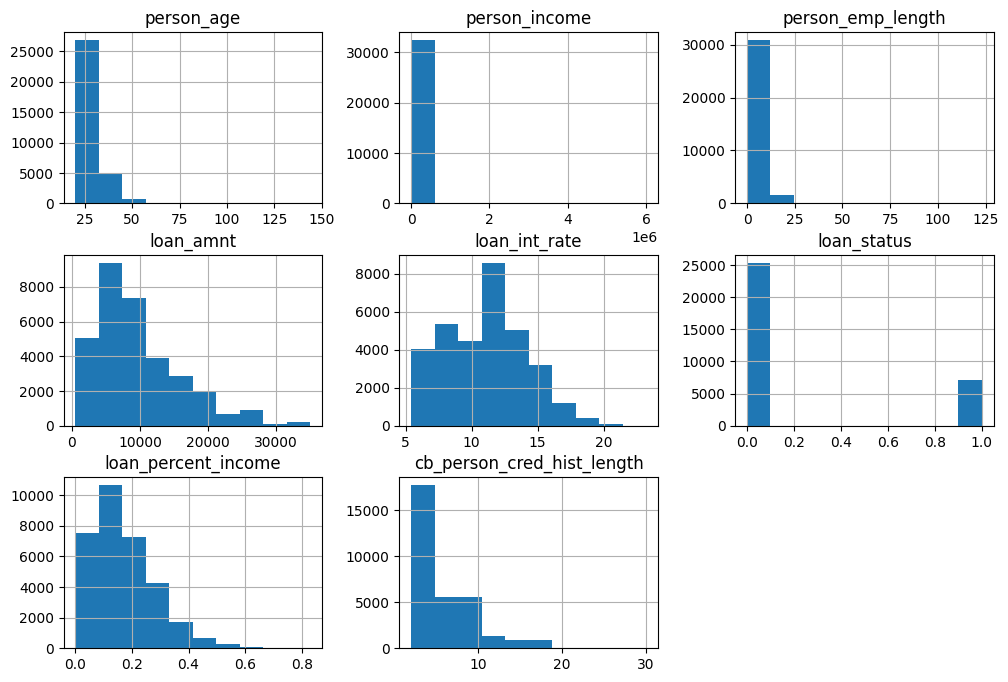

In [25]:
# Розподіл числових змінних
df[num_cols].hist(figsize=(12,8))
plt.show()

In [26]:
# Викиди в колонці person_income

Q1 = df["person_income"].quantile(0.25)
Q3 = df["person_income"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df["person_income"] >= lower)
        & (df["person_income"] <= upper)]

print(f"Після фільтрації в межі потрапляє {df.shape[0]} рядків")

Після фільтрації в межі потрапляє 30938 рядків


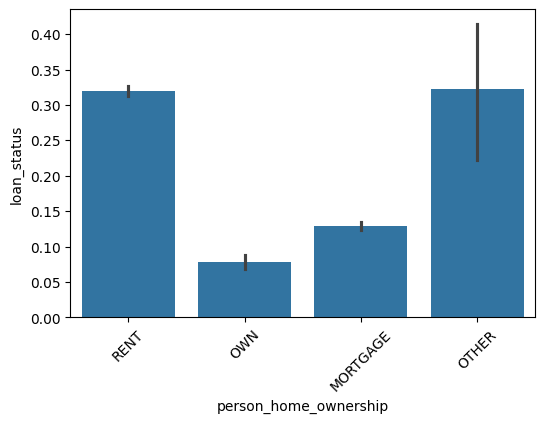

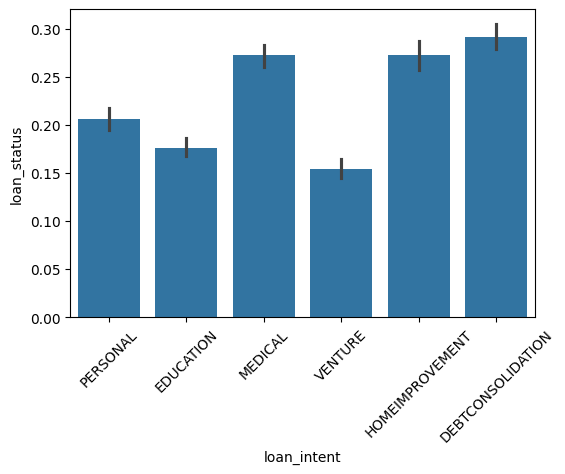

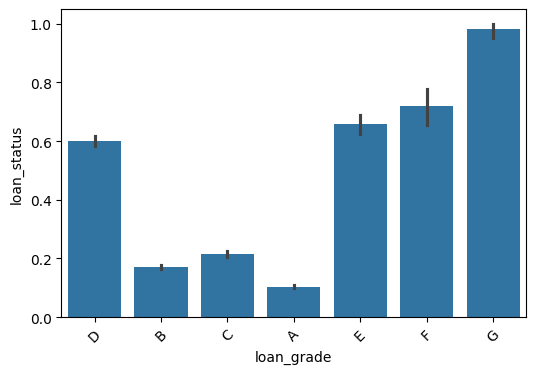

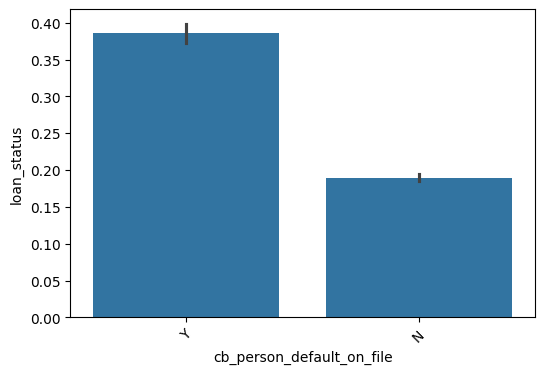

In [28]:
# Аналіз категоріальних змінних відносно цільової та частоту зустрічання різних значень в них
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='loan_status', data=df)
    plt.xticks(rotation=45)
    plt.show()

In [29]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())


 person_home_ownership
person_home_ownership
RENT        16037
MORTGAGE    12353
OWN          2449
OTHER          99
Name: count, dtype: int64

 loan_intent
loan_intent
EDUCATION            6161
MEDICAL              5817
VENTURE              5410
PERSONAL             5238
DEBTCONSOLIDATION    4933
HOMEIMPROVEMENT      3379
Name: count, dtype: int64

 loan_grade
loan_grade
A    10271
B     9864
C     6171
D     3453
E      898
F      221
G       60
Name: count, dtype: int64

 cb_person_default_on_file
cb_person_default_on_file
N    25482
Y     5456
Name: count, dtype: int64



---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



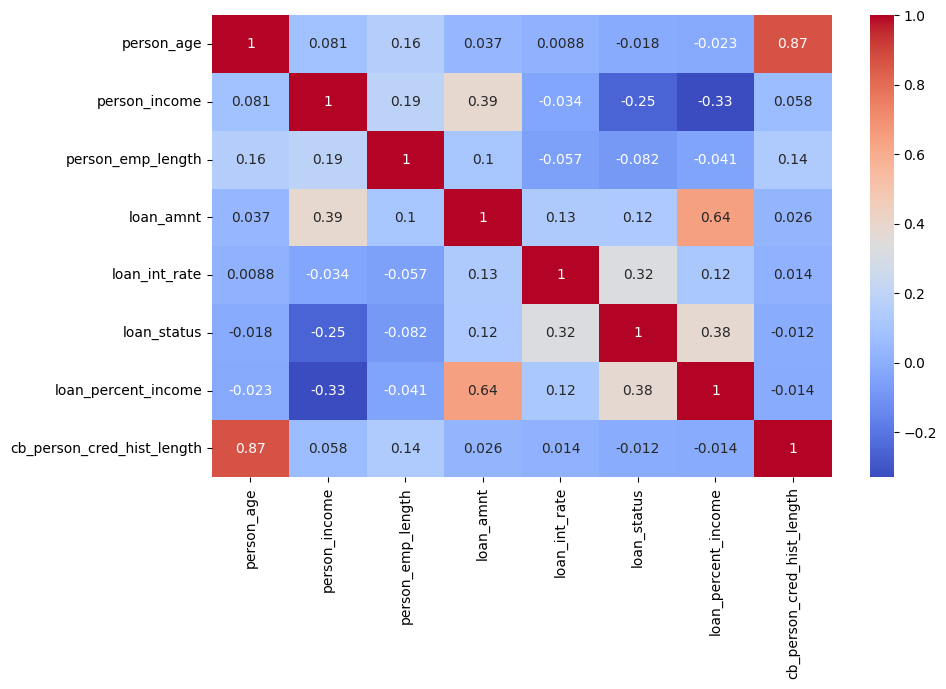

In [31]:
# Матриця кореляції для числових змінних
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [34]:
# Кодування категоріальних змінних
df_encoded = pd.get_dummies(
    df,
    columns=['person_home_ownership', 'loan_intent', 'loan_grade'],
    drop_first=True
)
df_encoded.shape

(30938, 23)

In [35]:
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22,59000,123.0,35000,16.02,1,0.59,Y,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False
1,21,9600,5.0,1000,11.14,0,0.10,N,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,N,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,N,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,Y,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False


In [36]:
df_encoded['cb_person_default_on_file'] = df_encoded['cb_person_default_on_file'].map({
    'Y': 1,
    'N': 0
})

In [37]:
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']

In [39]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30938, 22)
y shape: (30938,)



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [45]:
# Ділимо дані на X та y
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']

In [53]:
# Розділяємо на навчальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"Train: {X_train.shape[0]} клієнтів")
print(f"Test: {X_test.shape[0]} клієнтів")
print(f"Відтік train: {y_train.mean():.1%}")
print(f"Відтік test: {y_test.mean():.1%}")

Train: 24750 клієнтів
Test: 6188 клієнтів
Відтік train: 22.3%
Відтік test: 23.0%


In [54]:
# Застосовуємо  масштабування
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [55]:
from sklearn.linear_model import LogisticRegression

In [59]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Модель навчена")

Модель навчена


In [70]:
# Тренувальні і тестові прогнози
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
y_pred_proba

array([[0.92829637, 0.07170363],
       [0.87737231, 0.12262769],
       [0.97690935, 0.02309065],
       ...,
       [0.92154334, 0.07845666],
       [0.92863979, 0.07136021],
       [0.97872353, 0.02127647]])

In [71]:
sample_predictions = pd.DataFrame({
    'Реальний кредитний статус': y_test.values[:10],
    'Прогноз': y_pred[:10],
    'Ймовірність сплати': y_pred_proba[:10, 0].round(2),
    'Ймовірність дефолту': y_pred_proba[:10, 1].round(2)
})
print(sample_predictions)

   Реальний кредитний статус  Прогноз  Ймовірність сплати  Ймовірність дефолту
0                          0        0                0.93                 0.07
1                          0        0                0.88                 0.12
2                          0        0                0.98                 0.02
3                          0        0                0.90                 0.10
4                          0        1                0.25                 0.75
5                          0        0                0.93                 0.07
6                          0        0                0.97                 0.03
7                          0        0                0.98                 0.02
8                          1        0                0.62                 0.38
9                          0        0                0.94                 0.06



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

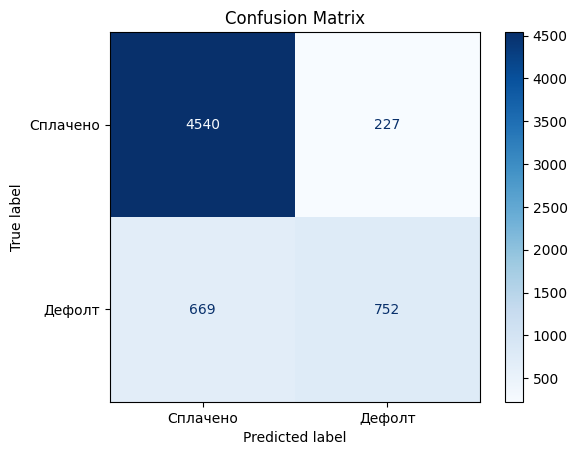

In [75]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Сплачено', 'Дефолт'])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Сплачено правильно 4540, дефолт правильно 752, сплачено неправильно 669, дефолт неправильно 227.

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



In [85]:
# Обчислюємо основні метрики (accuracy, precision, recall, f1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


In [86]:
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.2f}")
print(f"Precision (Влучність):  {precision:.2f}")
print(f"Recall (Повнота):       {recall:.2f}")
print(f"F1-score:               {f1:.2f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.86
Precision (Влучність):  0.77
Recall (Повнота):       0.53
F1-score:               0.63


In [87]:
# Побудова ROC-кривої та обчислення AUC
from sklearn.metrics import roc_curve, roc_auc_score



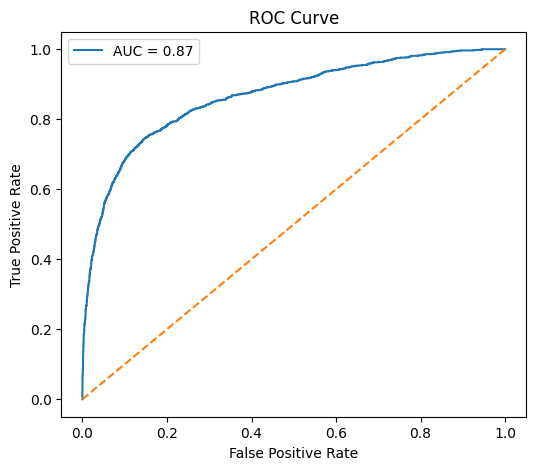

In [88]:
y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

AUC = 0.87 свідчить про те, що у нас хороша модель.

In [91]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance.round(2)

,feature,coefficient,abs_coefficient
21,loan_grade_G,4.35,4.35
20,loan_grade_F,2.66,2.66
19,loan_grade_E,2.48,2.48
18,loan_grade_D,2.30,2.30
9,person_home_ownership_OWN,-1.60,1.60
5,loan_percent_income,1.33,1.33
15,loan_intent_VENTURE,-1.06,1.06
11,loan_intent_EDUCATION,-0.84,0.84
10,person_home_ownership_RENT,0.84,0.84
14,loan_intent_PERSONAL,-0.67,0.67


Найбільш значущий вплив мають низькі кредитні рейтинги:

loan_grade_G (4.35)
loan_grade_F (2.66)
loan_grade_E (2.48)
loan_grade_D (2.30)
Серед інших суттєвих ознак:

loan_percent_income (1.33) — збільшення частки кредиту від доходу підвищує ризик дефолту
loan_amnt (-0.54) — впливає на модель, але менш значущо
loan_int_rate (0.26) — вищі ставки асоціюються з ризиковими позичальниками
person_home_ownership_OWN (-1.60) знижує ризик дефолту, що свідчить про вищу фінансову стабільність власників житла
person_home_ownership_RENT (0.84) навпаки підвищує ризик.

Висновок:
Модель показує, що основними факторами кредитного ризику є кредитний рейтинг позичальника та співвідношення кредиту до доходу. Соціально-економічні характеристики (наприклад, тип житла) також відіграють важливу роль, тоді як демографічні ознаки мають незначний вплив. Отримані результати відповідають логіці та підтверджують адекватність побудованої моделі.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [96]:
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)

fig.add_vline(x=0.5, line_dash="dash", line_color="gray", annotation_text="Початковий поріг 0.5")

fig.show()

Графік показує, що оптимальний поріг класифікацї складає 0.35.

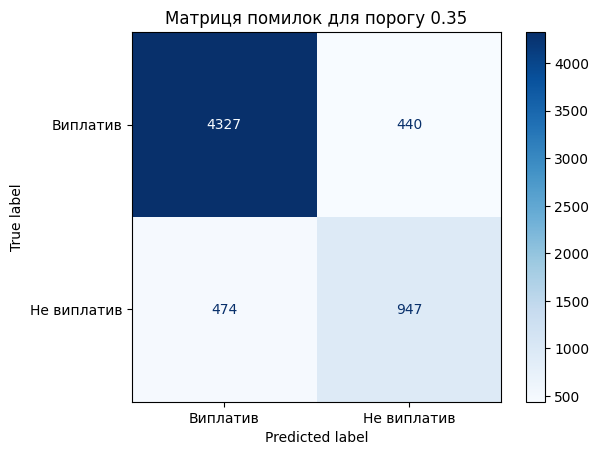

In [103]:
y_pred_opt = y_pred_proba[:, 1]>=0.35
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Виплатив", "Не виплатив"])
disp.plot(cmap="Blues")
plt.title("Матриця помилок для порогу 0.35")
plt.show()



---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.
